In [1]:
import numpy as np
from specs import *
from scipy.interpolate import interp1d
from meer21cm.telescope import dish_beam_sigma
import scipy.signal.windows as windows
from multiprocessing import Pool
from meer21cm.power import get_shot_noise_galaxy
from meer21cm.grid import shot_noise_correction_from_gridding
from astropy.cosmology import Planck18
from meer21cm.util import pca_clean
from meer21cm.transfer import (
    TransferFunction,
    run_tf_calculation_auto,
    run_tf_calculation_cross,
)
import matplotlib.pyplot as plt

In [2]:
fg_map = np.load("fg_map.npy")

In [3]:
seed = 0
mock = get_mock(seed)

In [4]:
freq_mask = mock.W_HI.copy()
freq_mask[:,:,50:100] = False
freq_mask[:,:,500:520] = False

In [9]:
mock.sigma_beam_ch = sigma_beam_ch
# remove buffer for a bigger simulation box
mock.W_HI = np.ones_like(mock.W_HI)
mock.w_HI = np.ones_like(mock.w_HI)
mock.downres_factor_transverse = sim_upres_transverse
mock.downres_factor_radial = sim_upres_radial
mock.get_enclosing_box()
mock.data = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
mock.trim_map_to_range()
# mask out the frequency gaps
mock.W_HI = mock.W_HI * freq_mask
mock.w_HI = mock.w_HI * freq_mask.astype('float')
# keep a copy of the hi map and the count map
hi_map = mock.data.copy()
count_map = mock.w_HI.copy()
mask_map = mock.W_HI.copy()
mock.grid_scheme = grid_scheme
mock.downres_factor_transverse = ps_downres_transverse
mock.downres_factor_radial = ps_downres_radial
mock.get_enclosing_box()

In [10]:
# add in the foreground
mock.data = fg_map.copy()
mock.w_HI = np.ones_like(mock.w_HI)
mock.W_HI = np.ones_like(mock.W_HI)
# convolve with the beam
mock.convolve_data(mock.beam_image)
mock.trim_map_to_range()
fg_map_beam = mock.data.copy()
tot_map = fg_map_beam + hi_map
mock.w_HI = count_map
mock.W_HI = mask_map
cov_tot, _, _, _ = pca_clean(
    tot_map,
    1,
    weights=mock.W_HI,
    return_analysis=True,
    mean_center=True,
)
# perform PCA cleaning
res_map, A_mat = pca_clean(
    tot_map,
    N_fg,
    weights=mock.W_HI,
    mean_center=True,
    covariance=cov_tot,
    return_A=True,
    ignore_nan=True,
)

/users/ztchen/meer21cm/src/meer21cm/util.py:809: RuntimeWarning: invalid value encountered in divide
  flat = flat - np.sum(flat * wflat, 1, keepdims=True) / np.sum(


In [14]:
# unmask the gaps
mock.w_HI = np.ones_like(mock.w_HI)
mock.W_HI = np.ones_like(mock.W_HI)
mock.trim_map_to_range()
cov_tot2, _, eival, eigvec = pca_clean(
    tot_map,
    1,
    weights=mock.W_HI,
    return_analysis=True,
    mean_center=True,
)
# perform PCA cleaning
res_map2, A_mat2 = pca_clean(
    tot_map,
    N_fg,
    weights=mock.W_HI,
    mean_center=True,
    covariance=cov_tot2,
    return_A=True,
)

In [ ]:
fig,axes = plt.subplots(4,1,figsize=(10,8),gridspec_kw={'hspace':0.05})
plt.rcParams.update({'font.size':17})
for i in range(4):
    axes[i].set_xlim(mock.nu.min()/1e6,mock.nu.max()/1e6)
axes[0].plot(mock.nu/1e6,freq_mask.sum((0,1))>0,lw=2,color='black')
axes[0].set_xlabel('Freq [MHz]')
axes[0].set_yticks([0,1])
axes[0].set_xticklabels([])
axes[0].set_ylabel('Sampling')
for i in range(3):
    axes[i+1].plot(mock.nu/1e6,A_mat[:,i],label='With gaps',lw=2)
    axes[i+1].plot(mock.nu/1e6,A_mat2[:,i],ls='--',label='Without gaps')
    if i != 2:
        axes[i+1].set_xticklabels([])
    else:
        axes[i+1].set_xlabel('Freq [MHz]')
axes[2].legend()
fig.suptitle('First three eigenvectors')
plt.savefig('plots/eiv_gaps.pdf',bbox_inches='tight')


/tmp/ipykernel_3366215/1206877962.py:34: RuntimeWarning: Mean of empty slice
  im = ax.imshow(np.nanmean(maps_i[:,:,:20],2).T,cmap='coolwarm',vmin=-0.1,vmax=0.1)


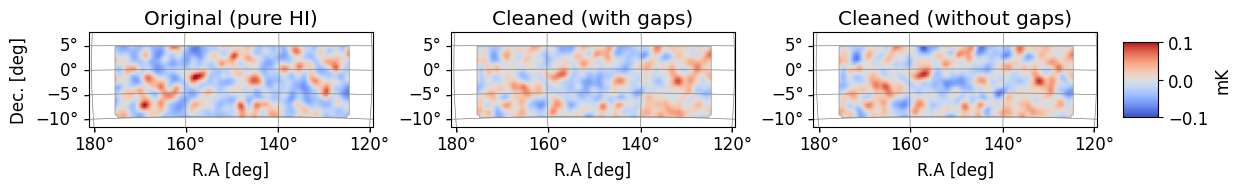

In [63]:
maps = [1e3*hi_map,1e3*res_map,1e3*res_map2]
plt.rcParams.update({'font.size':12})
titles = ['Original (pure HI)', 'Cleaned (with gaps)', 'Cleaned (without gaps)']
layout = """
AAAAAAAABBBBBBBBCCCCCCCC.
AAAAAAAABBBBBBBBCCCCCCCC.
AAAAAAAABBBBBBBBCCCCCCCC.
AAAAAAAABBBBBBBBCCCCCCCCD
AAAAAAAABBBBBBBBCCCCCCCCD
AAAAAAAABBBBBBBBCCCCCCCC.
AAAAAAAABBBBBBBBCCCCCCCC.
AAAAAAAABBBBBBBBCCCCCCCC.
"""
fig = plt.figure(layout="constrained",figsize=(12.3,5))
ax_dict = fig.subplot_mosaic(layout)

#fig,axes = plt.subplots(1,4,figsize=(12.3,5),
#                        width_ratios=[4,4,4,0.3])
axes = [ax_dict[i] for i in ['A','B', 'C', 'D']]
for i,ax in enumerate(axes[:3]):
    ss = ax.get_subplotspec()
    ax.remove()
    axes[i] = fig.add_subplot(ss, projection=mock.wproj)
for i in range(3):
    ax = axes[i]
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter('d')
    lon.set_ticks_position('b')
    lat.set_ticks_position('l')
    ax.grid(True, color='grey', ls='solid',lw=0.5)
    maps_i = maps[i]
    maps_i[mock.W_HI.sum(-1)==0]=np.nan
    im = ax.imshow(np.nanmean(maps_i[:,:,:20],2).T,cmap='coolwarm',vmin=-0.1,vmax=0.1)
    ax.set_xlabel('R.A [deg]')
    if i==0: ax.set_ylabel('Dec. [deg]')
    else: ax.set_ylabel('')
    ax.invert_xaxis()
    ax.set_title(titles[i])
cbar = plt.colorbar(im,cax=axes[-1],)
cbar.set_label('mK')
plt.savefig('plots/maps_gaps.pdf',bbox_inches='tight')